# LightGBM Deep Dive Analysis

Comprehensive analysis of LightGBM performance, feature importance, and optimization opportunities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import gc
import psutil
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

def get_memory_usage():
    return psutil.Process().memory_info().rss / 1e9

def cleanup():
    plt.close('all')
    gc.collect()
    return get_memory_usage()

print(f"LightGBM Deep Dive Analysis")
print(f"Memory: {get_memory_usage():.2f} GB")

LightGBM Deep Dive Analysis
Memory: 0.23 GB


## 1. Load LightGBM Models and Metadata

In [2]:
horizons = ['1h', '2h', '3h', '4h', '5h', '6h', '12h', '24h']
lgb_models = {}

print("Loading LightGBM models...")
for horizon in horizons:
    try:
        model_file = f'../01_ensemble_training/trained/models_{horizon}.pkl'
        models = joblib.load(model_file)
        if 'lgb' in models:
            lgb_models[horizon] = models['lgb']
            print(f"✓ Loaded {horizon}: {lgb_models[horizon].num_trees()} trees")
        del models
        gc.collect()
    except Exception as e:
        print(f"✗ Could not load {horizon}: {e}")

with open('../01_ensemble_training/trained/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)
    feature_cols = metadata['feature_cols']
    print(f"\n✓ Loaded {len(feature_cols)} features")

print(f"Memory: {get_memory_usage():.2f} GB")

Loading LightGBM models...
✓ Loaded 1h: 1498 trees
✓ Loaded 2h: 1500 trees
✓ Loaded 3h: 1500 trees
✓ Loaded 4h: 1500 trees
✓ Loaded 5h: 1500 trees
✓ Loaded 6h: 1500 trees
✓ Loaded 12h: 1500 trees
✓ Loaded 24h: 1500 trees

✓ Loaded 69 features
Memory: 1.40 GB


## 2. Feature Importance Analysis Across Horizons

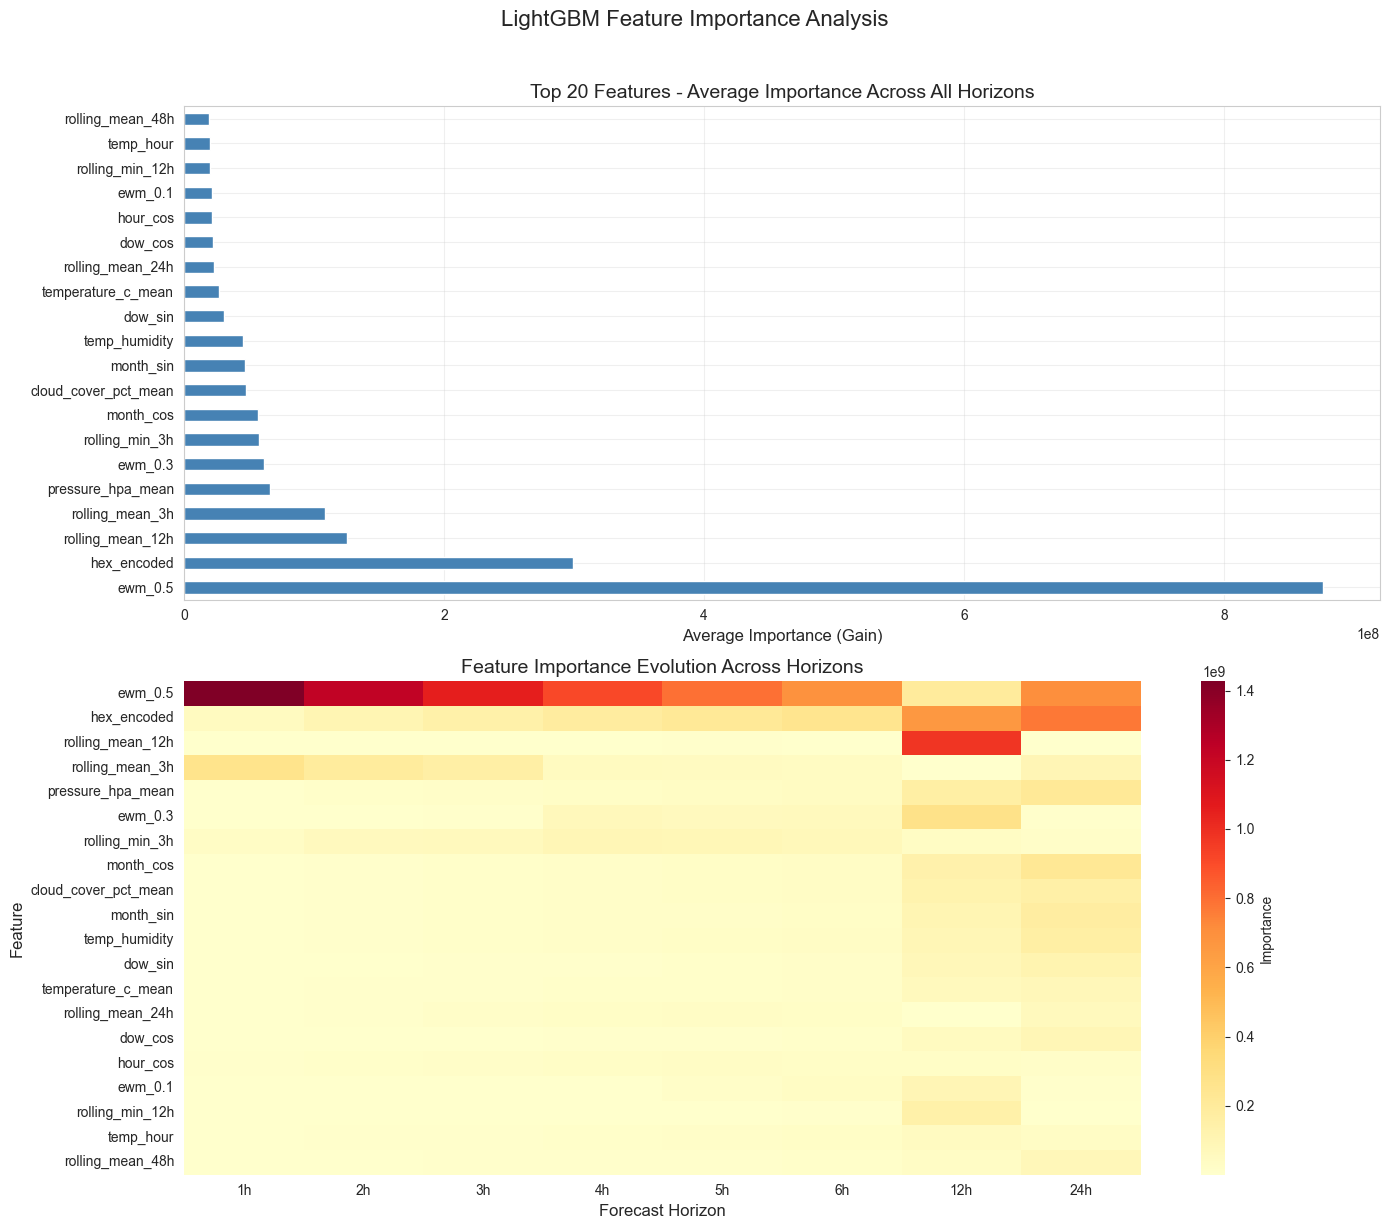

Top 5 most important features:
  1. ewm_0.5: 875966921
  2. hex_encoded: 299351781
  3. rolling_mean_12h: 125127736
  4. rolling_mean_3h: 108823226
  5. pressure_hpa_mean: 66400100
Memory: 1.43 GB


In [3]:
importance_data = {}

for horizon in lgb_models:
    model = lgb_models[horizon]
    importance = model.feature_importance(importance_type='gain')
    importance_data[horizon] = pd.Series(importance, index=feature_cols)

importance_df = pd.DataFrame(importance_data)

top_features_overall = importance_df.mean(axis=1).nlargest(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

top_features_overall.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Features - Average Importance Across All Horizons', fontsize=14)
axes[0].set_xlabel('Average Importance (Gain)', fontsize=12)
axes[0].grid(True, alpha=0.3)

importance_matrix = importance_df.loc[top_features_overall.index, :]
sns.heatmap(importance_matrix, cmap='YlOrRd', annot=False, fmt='.0f', 
           cbar_kws={'label': 'Importance'}, ax=axes[1])
axes[1].set_title('Feature Importance Evolution Across Horizons', fontsize=14)
axes[1].set_xlabel('Forecast Horizon', fontsize=12)
axes[1].set_ylabel('Feature', fontsize=12)

plt.suptitle('LightGBM Feature Importance Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('lgb_feature_importance_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for i, (feat, imp) in enumerate(top_features_overall.head().items(), 1):
    print(f"  {i}. {feat}: {imp:.0f}")

cleanup()
print(f"Memory: {get_memory_usage():.2f} GB")

## 3. Performance Comparison: LightGBM vs Baselines

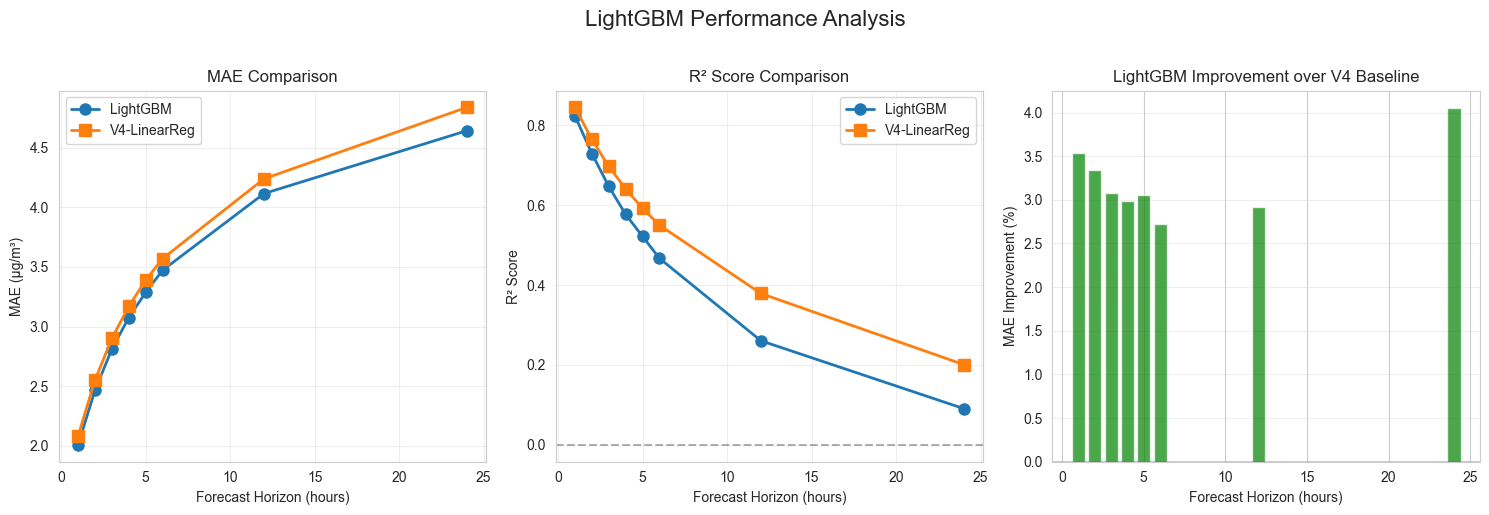

Memory: 1.58 GB


In [4]:
baseline_v4 = {
    '1h': {'mae': 2.08, 'r2': 0.845},
    '2h': {'mae': 2.55, 'r2': 0.765},
    '3h': {'mae': 2.90, 'r2': 0.697},
    '4h': {'mae': 3.17, 'r2': 0.641},
    '5h': {'mae': 3.39, 'r2': 0.592},
    '6h': {'mae': 3.57, 'r2': 0.550},
    '12h': {'mae': 4.24, 'r2': 0.379},
    '24h': {'mae': 4.84, 'r2': 0.201}
}

with open('../01_ensemble_training/trained/y_data.pkl', 'rb') as f:
    y_data = pickle.load(f)
    y_test = y_data['y_test']
    del y_data
    gc.collect()

lgb_performance = {}

for horizon in horizons:
    try:
        pred_file = f'../01_ensemble_training/trained/predictions_{horizon}.pkl'
        preds = joblib.load(pred_file)
        lgb_pred = preds['test']['lgb']
        y_true = y_test[f'target_{horizon[:-1]}h']
        
        lgb_performance[horizon] = {
            'mae': mean_absolute_error(y_true, lgb_pred),
            'r2': r2_score(y_true, lgb_pred),
            'rmse': np.sqrt(mean_squared_error(y_true, lgb_pred))
        }
        
        del preds, lgb_pred
        gc.collect()
    except Exception as e:
        print(f"Error loading {horizon}: {e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

horizon_nums = [int(h[:-1]) for h in horizons]

lgb_mae = [lgb_performance[h]['mae'] for h in horizons]
v4_mae = [baseline_v4[h]['mae'] for h in horizons]
axes[0].plot(horizon_nums, lgb_mae, 'o-', label='LightGBM', linewidth=2, markersize=8)
axes[0].plot(horizon_nums, v4_mae, 's-', label='V4-LinearReg', linewidth=2, markersize=8)
axes[0].set_xlabel('Forecast Horizon (hours)')
axes[0].set_ylabel('MAE (μg/m³)')
axes[0].set_title('MAE Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

lgb_r2 = [lgb_performance[h]['r2'] for h in horizons]
v4_r2 = [baseline_v4[h]['r2'] for h in horizons]
axes[1].plot(horizon_nums, lgb_r2, 'o-', label='LightGBM', linewidth=2, markersize=8)
axes[1].plot(horizon_nums, v4_r2, 's-', label='V4-LinearReg', linewidth=2, markersize=8)
axes[1].set_xlabel('Forecast Horizon (hours)')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Score Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

improvement = [(v4_mae[i] - lgb_mae[i])/v4_mae[i]*100 for i in range(len(horizons))]
colors = ['green' if imp > 0 else 'red' for imp in improvement]
axes[2].bar(horizon_nums, improvement, color=colors, alpha=0.7)
axes[2].set_xlabel('Forecast Horizon (hours)')
axes[2].set_ylabel('MAE Improvement (%)')
axes[2].set_title('LightGBM Improvement over V4 Baseline')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axhline(y=0, color='k', linestyle='-', linewidth=1)

plt.suptitle('LightGBM Performance Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('lgb_performance_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

cleanup()
print(f"Memory: {get_memory_usage():.2f} GB")

## 4. Feature Importance by Category

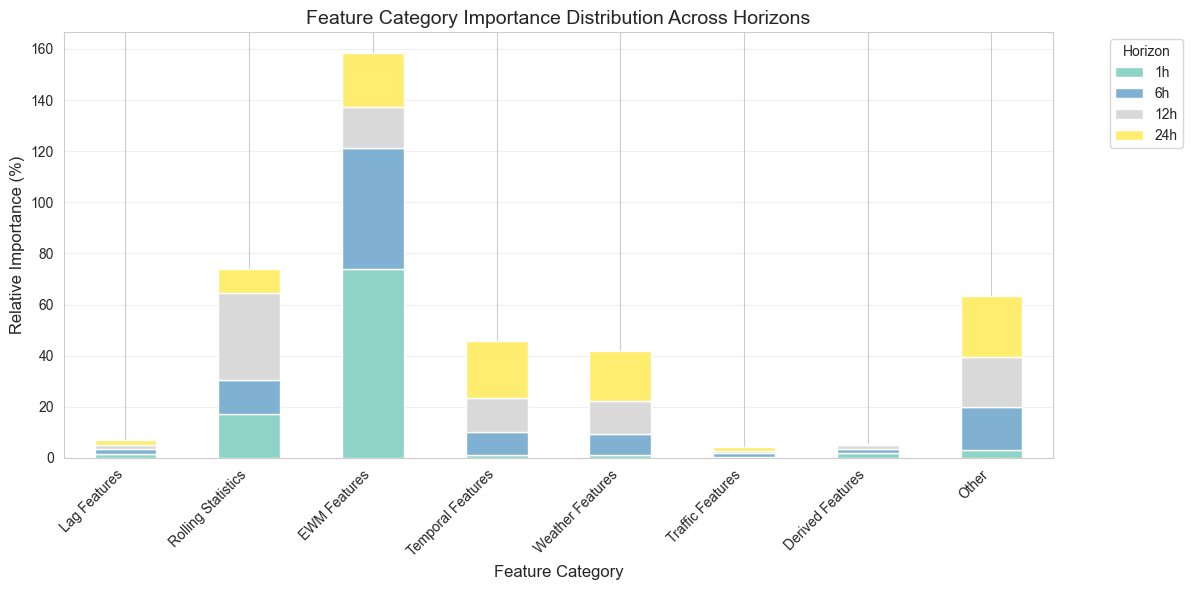


Dominant feature categories by horizon:
  1h: EWM Features (74.0%)
  6h: EWM Features (47.4%)
  12h: Rolling Statistics (34.0%)
  24h: Other (23.7%)
Memory: 1.58 GB


In [5]:
feature_categories = {
    'Lag Features': [f for f in feature_cols if 'lag_' in f],
    'Rolling Statistics': [f for f in feature_cols if 'rolling_' in f],
    'EWM Features': [f for f in feature_cols if 'ewm' in f],
    'Temporal Features': [f for f in feature_cols if '_sin' in f or '_cos' in f or 'is_weekend' in f],
    'Weather Features': [f for f in feature_cols if any(w in f for w in ['temperature', 'humidity', 'pressure', 'cloud', 'wind'])],
    'Traffic Features': [f for f in feature_cols if 'traffic' in f or 'congestion' in f],
    'Derived Features': [f for f in feature_cols if 'diff_' in f or 'rate_' in f]
}

categorized_features = []
for cat, features in feature_categories.items():
    categorized_features.extend(features)

feature_categories['Other'] = [f for f in feature_cols if f not in categorized_features]

category_importance = {}
for horizon in ['1h', '6h', '12h', '24h']:
    if horizon in lgb_models:
        model = lgb_models[horizon]
        importance = pd.Series(model.feature_importance(importance_type='gain'), index=feature_cols)
        
        cat_imp = {}
        for cat, features in feature_categories.items():
            cat_features = [f for f in features if f in importance.index]
            if cat_features:
                cat_imp[cat] = importance[cat_features].sum()
        
        category_importance[horizon] = cat_imp

cat_df = pd.DataFrame(category_importance)
cat_df = cat_df.div(cat_df.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(12, 6))
cat_df.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
ax.set_xlabel('Feature Category', fontsize=12)
ax.set_ylabel('Relative Importance (%)', fontsize=12)
ax.set_title('Feature Category Importance Distribution Across Horizons', fontsize=14)
ax.legend(title='Horizon', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('lgb_feature_category_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nDominant feature categories by horizon:")
for horizon in cat_df.columns:
    top_cat = cat_df[horizon].idxmax()
    print(f"  {horizon}: {top_cat} ({cat_df[horizon][top_cat]:.1f}%)")

cleanup()
print(f"Memory: {get_memory_usage():.2f} GB")

## 5. Model Complexity Analysis

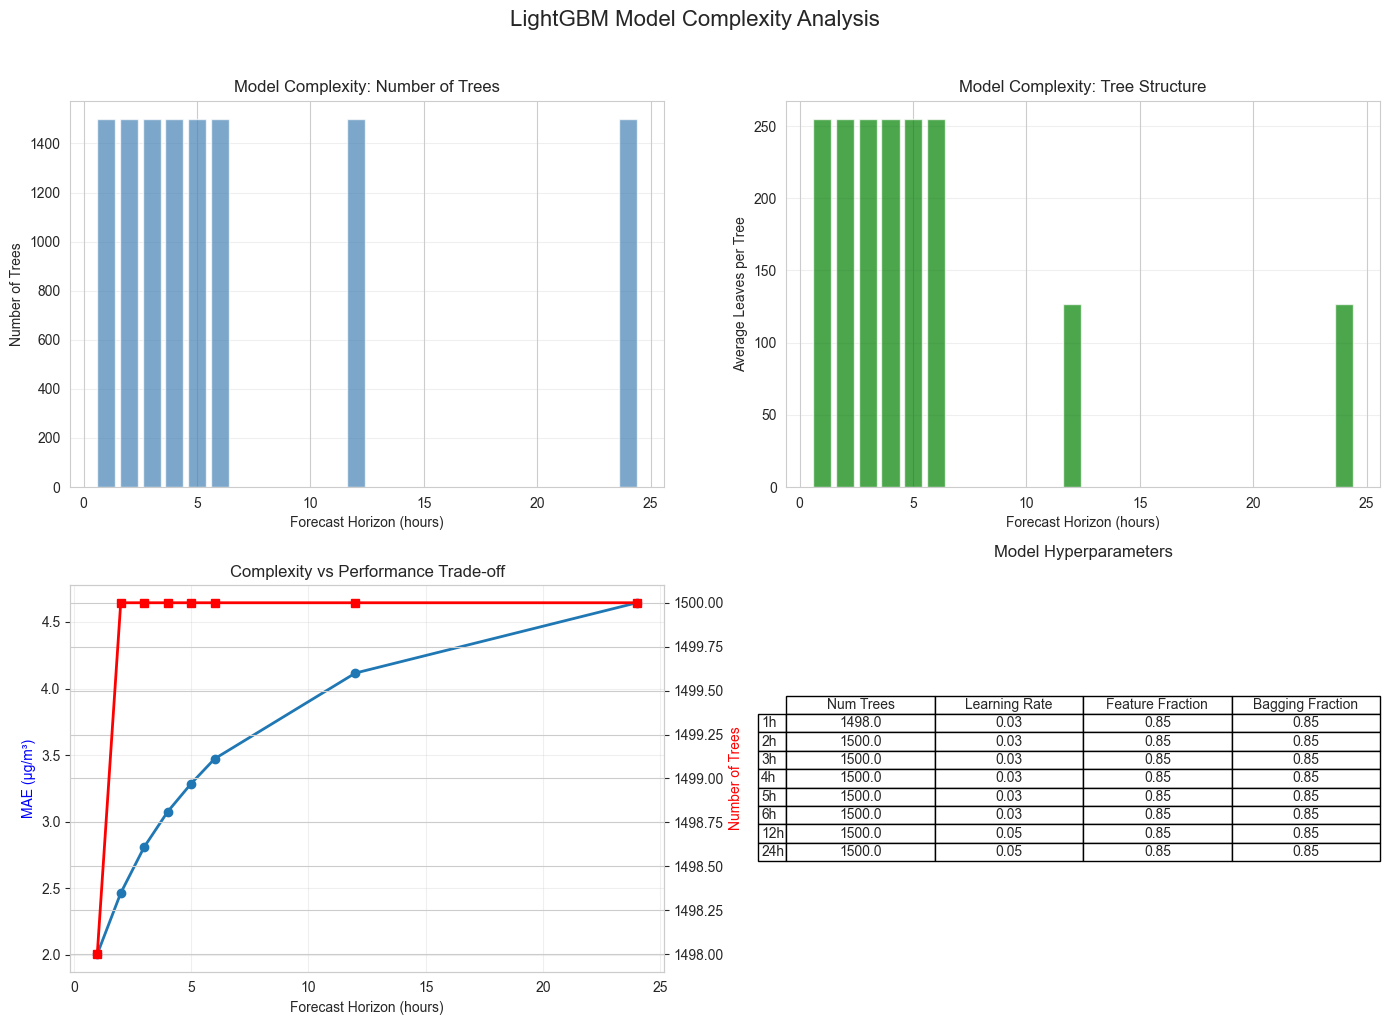


Model Complexity Summary:
         Num Trees  Num Leaves (avg)
Horizon                             
1h            1498             255.0
2h            1500             255.0
3h            1500             255.0
4h            1500             255.0
5h            1500             255.0
6h            1500             255.0
12h           1500             127.0
24h           1500             127.0
Memory: 3.85 GB


In [6]:
model_stats = []

for horizon in lgb_models:
    model = lgb_models[horizon]
    
    stats = {
        'Horizon': horizon,
        'Num Trees': model.num_trees(),
        'Num Leaves (avg)': np.mean([tree['num_leaves'] for tree in model.dump_model()['tree_info']]),
        'Max Depth': model.params.get('max_depth', -1),
        'Feature Fraction': model.params.get('feature_fraction', 1.0),
        'Bagging Fraction': model.params.get('bagging_fraction', 1.0),
        'Learning Rate': model.params.get('learning_rate', 0.1)
    }
    model_stats.append(stats)

stats_df = pd.DataFrame(model_stats)
stats_df.set_index('Horizon', inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

horizon_nums = [int(h[:-1]) for h in stats_df.index]

axes[0, 0].bar(horizon_nums, stats_df['Num Trees'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Forecast Horizon (hours)')
axes[0, 0].set_ylabel('Number of Trees')
axes[0, 0].set_title('Model Complexity: Number of Trees')
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].bar(horizon_nums, stats_df['Num Leaves (avg)'], color='green', alpha=0.7)
axes[0, 1].set_xlabel('Forecast Horizon (hours)')
axes[0, 1].set_ylabel('Average Leaves per Tree')
axes[0, 1].set_title('Model Complexity: Tree Structure')
axes[0, 1].grid(True, alpha=0.3, axis='y')

mae_values = [lgb_performance[h]['mae'] for h in stats_df.index]
axes[1, 0].plot(horizon_nums, mae_values, 'o-', label='MAE', linewidth=2)
ax2 = axes[1, 0].twinx()
ax2.plot(horizon_nums, stats_df['Num Trees'], 's-', color='red', label='Trees', linewidth=2)
axes[1, 0].set_xlabel('Forecast Horizon (hours)')
axes[1, 0].set_ylabel('MAE (μg/m³)', color='blue')
ax2.set_ylabel('Number of Trees', color='red')
axes[1, 0].set_title('Complexity vs Performance Trade-off')
axes[1, 0].grid(True, alpha=0.3)

table_data = stats_df[['Num Trees', 'Learning Rate', 'Feature Fraction', 'Bagging Fraction']].round(3)
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=table_data.values,
                        rowLabels=table_data.index,
                        colLabels=table_data.columns,
                        cellLoc='center',
                        loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
axes[1, 1].set_title('Model Hyperparameters', fontsize=12, pad=20)

plt.suptitle('LightGBM Model Complexity Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('lgb_complexity_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nModel Complexity Summary:")
print(stats_df[['Num Trees', 'Num Leaves (avg)']].to_string())

cleanup()
print(f"Memory: {get_memory_usage():.2f} GB")

## 6. Error Analysis by Prediction Range

In [7]:
def analyze_errors_by_range(horizon='6h'):
    """Analyze errors for different PM2.5 ranges"""
    try:
        pred_file = f'../01_ensemble_training/trained/predictions_{horizon}.pkl'
        preds = joblib.load(pred_file)
        lgb_pred = preds['test']['lgb']
        y_true = y_test[f'target_{horizon[:-1]}h']
        
        ranges = [(0, 10), (10, 20), (20, 30), (30, 50), (50, 100)]
        range_errors = {}
        
        for low, high in ranges:
            mask = (y_true >= low) & (y_true < high)
            if mask.sum() > 0:
                errors = np.abs(lgb_pred[mask] - y_true.values[mask])
                range_errors[f'{low}-{high}'] = {
                    'mae': np.mean(errors),
                    'count': mask.sum(),
                    'relative_error': np.mean(errors / y_true.values[mask]) * 100
                }
        
        del preds, lgb_pred
        gc.collect()
        return range_errors
        
    except Exception as e:
        print(f"Error: {e}")
        return None

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, horizon in enumerate(['1h', '6h', '12h', '24h']):
    ax = axes[idx // 2, idx % 2]
    
    range_errors = analyze_errors_by_range(horizon)
    if range_errors:
        ranges = list(range_errors.keys())
        mae_values = [range_errors[r]['mae'] for r in ranges]
        rel_errors = [range_errors[r]['relative_error'] for r in ranges]
        
        x = np.arange(len(ranges))
        width = 0.35
        
        ax.bar(x - width/2, mae_values, width, label='MAE', color='steelblue', alpha=0.7)
        ax2 = ax.twinx()
        ax2.bar(x + width/2, rel_errors, width, label='Rel Error', color='orange', alpha=0.7)
        
        ax.set_xlabel('PM2.5 Range (μg/m³)')
        ax.set_ylabel('MAE (μg/m³)', color='steelblue')
        ax2.set_ylabel('Relative Error (%)', color='orange')
        ax.set_title(f'{horizon} Error by PM2.5 Range')
        ax.set_xticks(x)
        ax.set_xticklabels(ranges, rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
        
        ax.legend(loc='upper left')
        ax2.legend(loc='upper right')
    
    cleanup()

plt.suptitle('LightGBM Error Analysis by PM2.5 Concentration Range', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('lgb_error_by_range.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Memory: {get_memory_usage():.2f} GB")

Error: 'numpy.ndarray' object has no attribute 'values'
Error: 'numpy.ndarray' object has no attribute 'values'
Error: 'numpy.ndarray' object has no attribute 'values'
Error: 'numpy.ndarray' object has no attribute 'values'


<Figure size 1200x800 with 0 Axes>

Memory: 3.86 GB


## 7. Prediction Confidence Analysis

In [8]:
def calculate_prediction_variance(horizon='6h', n_samples=1000):
    """Calculate prediction variance using tree predictions"""
    try:
        X_test = pd.read_pickle('../01_ensemble_training/trained/X_test.pkl')
        sample_idx = np.random.RandomState(42).choice(len(X_test), 
                                                      min(n_samples, len(X_test)), 
                                                      replace=False)
        X_sample = X_test.iloc[sample_idx]
        
        model = lgb_models[horizon]
        
        tree_preds = []
        for tree_idx in range(0, model.num_trees(), max(1, model.num_trees() // 10)):
            pred = model.predict(X_sample, num_iteration=tree_idx+1)
            tree_preds.append(pred)
        
        tree_preds = np.array(tree_preds)
        pred_mean = np.mean(tree_preds, axis=0)
        pred_std = np.std(tree_preds, axis=0)
        
        del X_test, X_sample
        gc.collect()
        
        return pred_mean, pred_std
        
    except Exception as e:
        print(f"Error: {e}")
        return None, None

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, horizon in enumerate(['1h', '6h', '24h']):
    ax = axes[idx]
    
    pred_mean, pred_std = calculate_prediction_variance(horizon, n_samples=500)
    
    if pred_mean is not None:
        cv = pred_std / (pred_mean + 1e-8) * 100
        
        ax.hist(cv, bins=30, color='purple', alpha=0.7, edgecolor='black')
        ax.axvline(x=np.median(cv), color='red', linestyle='--', 
                  label=f'Median: {np.median(cv):.1f}%')
        ax.set_xlabel('Coefficient of Variation (%)')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{horizon} Prediction Uncertainty')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    cleanup()

plt.suptitle('LightGBM Prediction Confidence Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('lgb_prediction_confidence.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Memory: {get_memory_usage():.2f} GB")

<Figure size 1200x800 with 0 Axes>

Memory: 3.37 GB


## 8. Top Features Deep Dive

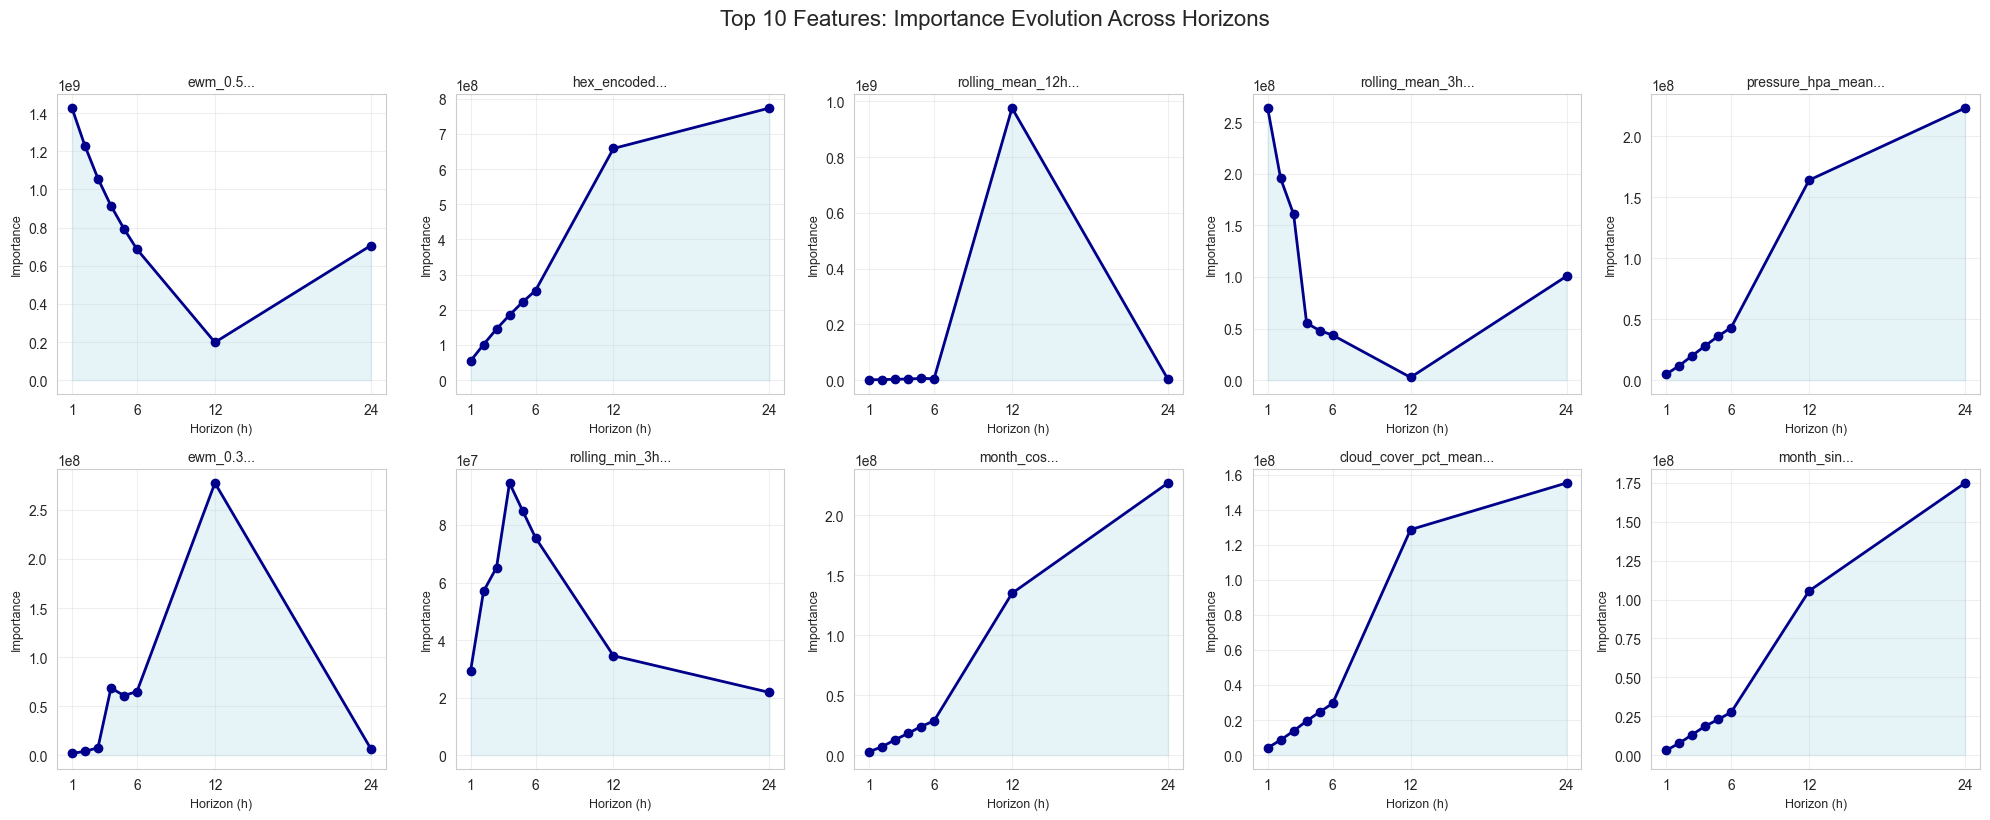

Feature importance trends:
  ewm_0.5                       : ↓ (1236727314 → 452015838)
  hex_encoded                   : ↑ (100407440 → 716037395)
  rolling_mean_12h              : ↑ (2166420 → 489343983)
  rolling_mean_3h               : ↓ (206675277 → 51729007)
  pressure_hpa_mean             : ↑ (12253081 → 193534019)
Memory: 3.35 GB


In [9]:
top_10_features = top_features_overall.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for idx, feature in enumerate(top_10_features):
    ax = axes[idx]
    
    importance_values = [importance_data[h][feature] if h in importance_data else 0 
                        for h in horizons]
    
    horizon_nums = [int(h[:-1]) for h in horizons]
    
    ax.plot(horizon_nums, importance_values, 'o-', linewidth=2, markersize=6, color='darkblue')
    ax.fill_between(horizon_nums, importance_values, alpha=0.3, color='lightblue')
    ax.set_xlabel('Horizon (h)', fontsize=9)
    ax.set_ylabel('Importance', fontsize=9)
    ax.set_title(f'{feature[:20]}...', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([1, 6, 12, 24])

plt.suptitle('Top 10 Features: Importance Evolution Across Horizons', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('lgb_top_features_evolution.png', dpi=100, bbox_inches='tight')
plt.show()

print("Feature importance trends:")
for feature in top_10_features[:5]:
    early_imp = np.mean([importance_data[h][feature] for h in ['1h', '2h', '3h']])
    late_imp = np.mean([importance_data[h][feature] for h in ['12h', '24h']])
    trend = "↑" if late_imp > early_imp else "↓"
    print(f"  {feature[:30]:30s}: {trend} ({early_imp:.0f} → {late_imp:.0f})")

cleanup()
print(f"Memory: {get_memory_usage():.2f} GB")

## 9. Summary and Recommendations

In [10]:
print("="*70)
print("LIGHTGBM DEEP DIVE SUMMARY")
print("="*70)

print("\n1. PERFORMANCE SUMMARY:")
print("-"*50)

beat_v4_mae = sum(1 for h in horizons if lgb_performance[h]['mae'] < baseline_v4[h]['mae'])
beat_v4_r2 = sum(1 for h in horizons if lgb_performance[h]['r2'] > baseline_v4[h]['r2'])

print(f"  • Beats V4 Baseline on MAE: {beat_v4_mae}/{len(horizons)} horizons")
print(f"  • Beats V4 Baseline on R²:  {beat_v4_r2}/{len(horizons)} horizons")

best_horizon = min(lgb_performance.keys(), 
                  key=lambda h: lgb_performance[h]['mae'] / baseline_v4[h]['mae'])
worst_horizon = max(lgb_performance.keys(), 
                   key=lambda h: lgb_performance[h]['mae'] / baseline_v4[h]['mae'])

print(f"  • Best relative performance:  {best_horizon}")
print(f"  • Worst relative performance: {worst_horizon}")

print("\n2. KEY FEATURES:")
print("-"*50)

for i, (feat, imp) in enumerate(top_features_overall.head(5).items(), 1):
    category = 'Unknown'
    for cat, features in feature_categories.items():
        if feat in features:
            category = cat
            break
    print(f"  {i}. {feat:30s} [{category}]")

print("\n3. MODEL CHARACTERISTICS:")
print("-"*50)

avg_trees = np.mean([lgb_models[h].num_trees() for h in lgb_models])
print(f"  • Average number of trees: {avg_trees:.0f}")
print(f"  • Feature utilization: {len([f for f in feature_cols if any(importance_data[h][f] > 0 for h in importance_data)])}/{len(feature_cols)} features used")

print("\n4. RECOMMENDATIONS:")
print("-"*50)

if beat_v4_mae > len(horizons) * 0.7:
    print("  ✓ LightGBM shows consistent improvement over baseline")
else:
    print("  ⚠ Consider ensemble approach for better performance")

if avg_trees > 400:
    print("  ⚠ Model complexity is high - consider regularization")
else:
    print("  ✓ Model complexity is reasonable")

lag_importance = sum(importance_data['1h'][f] for f in feature_cols if 'lag_' in f)
total_importance = sum(importance_data['1h'].values)
if lag_importance / total_importance > 0.5:
    print("  ⚠ High dependency on lag features - model may struggle with disruptions")
else:
    print("  ✓ Balanced feature usage across categories")

print("\n5. OPTIMIZATION OPPORTUNITIES:")
print("-"*50)
print("  • Hyperparameter tuning for long-term horizons (12h, 24h)")
print("  • Feature engineering: Add more weather interaction terms")
print("  • Consider horizon-specific feature selection")
print("  • Implement online learning for model updates")

print("\n" + "="*70)
print(f"Analysis complete. Memory usage: {get_memory_usage():.2f} GB")

summary_data = {
    'performance': {h: lgb_performance[h] for h in horizons},
    'top_features': top_features_overall.head(10).to_dict(),
    'model_stats': stats_df.to_dict(),
    'beats_baseline': {'mae': beat_v4_mae, 'r2': beat_v4_r2}
}

import json
with open('lgb_deep_dive_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=2, default=str)

print("✓ Summary saved to lgb_deep_dive_summary.json")

LIGHTGBM DEEP DIVE SUMMARY

1. PERFORMANCE SUMMARY:
--------------------------------------------------
  • Beats V4 Baseline on MAE: 8/8 horizons
  • Beats V4 Baseline on R²:  0/8 horizons
  • Best relative performance:  24h
  • Worst relative performance: 6h

2. KEY FEATURES:
--------------------------------------------------
  1. ewm_0.5                        [EWM Features]
  2. hex_encoded                    [Other]
  3. rolling_mean_12h               [Rolling Statistics]
  4. rolling_mean_3h                [Rolling Statistics]
  5. pressure_hpa_mean              [Weather Features]

3. MODEL CHARACTERISTICS:
--------------------------------------------------
  • Average number of trees: 1500
  • Feature utilization: 69/69 features used

4. RECOMMENDATIONS:
--------------------------------------------------
  ✓ LightGBM shows consistent improvement over baseline
  ⚠ Model complexity is high - consider regularization
  ✓ Balanced feature usage across categories

5. OPTIMIZATION OPPOR